# Guide pas a pas — des donnees EDA a l'optimisation du bloc operatoire

Ce notebook explique **comment les donnees pretraitees par `EDA_donees_bloc.ipynb`
alimentent le moteur de metaheuristiques** (`optimizer.py`), puis compare les
methodes disponibles :

| # | Methode | Role |
|---|---|---|
| 1 | Recuit simule | exploration par acceptance de Metropolis |
| 2 | Recherche Tabou | descente guidee avec memoire des mouvements |
| 3 | Algorithme genetique | population, croisement, mutation |
| 4 | **Hybride Tabou x Recuit** | voisinage tabou + acceptance type recuit |
| 5 | **Fourmis (ACO)** | construction par pheromones |

> Ce notebook est **autonome et non destructif** : il ne modifie ni
> `EDA_donees_bloc.ipynb`, ni le classeur source. Il lit le Parquet que le
> notebook EDA produit, ou bascule sur un jeu synthetique si ce Parquet est
> absent.

## 0. Rappel du pipeline

```
xlsx brut
   |  (EDA_donees_bloc.ipynb : nettoyage, exclusions, durees, horaires)
   v
resources/donnees_bloc_pretraitees.parquet   (1 ligne = 1 intervention)
   |  (data_bridge.py : selection d'horizon, proxy specialite, duree, sejour)
   v
patients + vacations  ---->  optimizer.py  ---->  planning + convergence
```


## 1. Imports et reglages

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Rendre le package importable quel que soit le dossier de lancement
# (racine du depot ou notebooks/).
REPO = Path.cwd()
if not (REPO / "optimiseur").is_dir() and (REPO.parent / "optimiseur").is_dir():
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from optimiseur import data_bridge as db
from optimiseur import optimizer as op
from optimiseur import plotting as pl

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

## 2. Dependance a `EDA_donees_bloc.ipynb`

Le notebook EDA est la **source de verite** du pretraitement. Il produit
`resources/donnees_bloc_pretraitees.parquet`, dont les colonnes utiles ici sont
notamment `date_inter`, `room_duration_min`, `duree_sejour_corrigee`,
`ccam_1` / `ghm_code` / `interv_type`.

Si le Parquet n'existe pas encore, on retombe sur un jeu synthetique pour que
le notebook reste executable de bout en bout. Dans ce cas, executez d'abord
`EDA_donees_bloc.ipynb` pour utiliser vos vraies donnees.

In [2]:
PARQUET_EDA = REPO / "resources" / "donnees_bloc_pretraitees.parquet"
DONNEES_REELLES = PARQUET_EDA.exists()

if DONNEES_REELLES:
    patients, vacations, contexte = db.prepare_inputs(
        PARQUET_EDA, horizon_jours=5, capacite_min=480
    )
    source = f"Donnees reelles issues de {PARQUET_EDA}"
else:
    patients, vacations = op.generate_test_data(n_patients=30, n_days=5)
    contexte = {
        "n_patients": len(patients),
        "n_vacations": len(vacations),
        "specialites": sorted(patients["specialite"].unique().tolist()),
        "capacite_min": 240,
    }
    source = "Jeu synthetique (Parquet EDA absent — lancez d'abord EDA_donees_bloc.ipynb)"

print(source)
display(patients.head())
display(vacations.head())

Donnees reelles issues de /home/youri/projets/IAS__metaheuristics/resources/donnees_bloc_pretraitees.parquet


,patient_id,specialite,duree_operatoire,duree_sejour,jour_origine
0,0,N,44,1,0
1,1,N,80,1,0
2,2,E,53,1,0
3,3,Autre,15,1,0
4,4,N,136,3,0


,vacation_id,jour,specialite,capacite_min
0,0,0,A,480
1,1,0,Autre,480
2,2,0,E,480
3,3,0,L,480
4,4,0,M,480


## 3. Contrat d'entree du moteur d'optimisation

`optimizer.py` attend **deux tables** :

- **patients** : `patient_id`, `specialite`, `duree_operatoire` (min),
  `duree_sejour` (jours)
- **vacations** : `vacation_id`, `jour`, `specialite`, `capacite_min` (min)

`data_bridge.py` fait la conversion depuis le Parquet EDA :

- `specialite` est un **proxy** derive de `ccam_1` (1re lettre = zone
  anatomique), sinon `ghm_code`, sinon `interv_type`. Il doit etre valide
  cliniquement avant toute conclusion.
- `duree_operatoire` <- `room_duration_min` (manquants completes par mediane
  par specialite).
- `duree_sejour` <- `duree_sejour_corrigee`.
- Seules les interventions des `horizon_jours` dernieres dates sont retenues
  (une "semaine" de planning realiste), puis reindexees en jours `0..n-1`.
- Les identifiants (`no_cas`, `id_patient`, `praticien`, `nom_chir`) sont
  ecartes.

In [3]:
if DONNEES_REELLES:
    print("Contexte de la fenetre retenue :")
    for cle, valeur in contexte.items():
        print(f"  {cle}: {valeur}")

print("\nSpecialites utilisees comme proxy :", contexte["specialites"])
print("Patients a planifier :", len(patients))
print("Vacations disponibles :", len(vacations))

Contexte de la fenetre retenue :
  dates: [Timestamp('2022-12-22 00:00:00'), Timestamp('2022-12-23 00:00:00'), Timestamp('2022-12-27 00:00:00'), Timestamp('2022-12-28 00:00:00'), Timestamp('2022-12-30 00:00:00')]
  mapping: {Timestamp('2022-12-22 00:00:00'): 0, Timestamp('2022-12-23 00:00:00'): 1, Timestamp('2022-12-27 00:00:00'): 2, Timestamp('2022-12-28 00:00:00'): 3, Timestamp('2022-12-30 00:00:00'): 4}
  n_days: 5
  n_patients: 45
  n_vacations: 35
  specialites: ['A', 'Autre', 'E', 'L', 'M', 'N', 'P']
  capacite_min: 480

Specialites utilisees comme proxy : ['A', 'Autre', 'E', 'L', 'M', 'N', 'P']
Patients a planifier : 45
Vacations disponibles : 35


## 4. Le modele et la fonction de qualite

Une **solution** est un dictionnaire `patient_id -> indice de vacation`
(convention interne). La fonction de qualite minimise :

```
cout = w_vacation * depassement_capacite_vacations
     + w_lits     * depassement_capacite_lits
     + w_balance  * ecart-type de la charge entre vacations
```

`fitness = -cout` : **on maximise**, et `0` correspond a un planning sans
aucune tension. Les poids sont reglables dans `PlanningProblem`.

In [4]:
problem = op.PlanningProblem(patients, vacations, lits_capacity=42)
print(f"{problem.n_patients} patients, {problem.n_vacations} vacations, {problem.n_days} jours")
print(f"Poids : w_vacation={problem.w_vacation}, w_lits={problem.w_lits}, w_balance={problem.w_balance}")

solution_aleatoire = problem.random_solution()
print(f"\nFitness d'une solution aleatoire : {problem.fitness(solution_aleatoire):.3f}")

45 patients, 35 vacations, 5 jours
Poids : w_vacation=5.0, w_lits=3.0, w_balance=0.05

Fitness d'une solution aleatoire : -4.443


## 5. Recuit simule

A chaque iteration, on tire un voisin. Une amelioration est toujours acceptee ;
une degradation est acceptee avec la probabilite `exp(delta / T)`. La
temperature `T` decroit geometriquement (`T *= alpha`), ce qui fait passer
d'une exploration large a un affinage local.

In [5]:
res_sa = op.simulated_annealing(problem, T0=50.0, alpha=0.95, n_iter=4000, seed=0)
print(f"Recuit simule : fitness = {res_sa.meilleure_fitness:.3f} en {res_sa.duree_s:.2f} s")

Recuit simule : fitness = -3.256 en 0.31 s


## 6. Recherche Tabou

On explore un voisinage, on choisit le meilleur mouvement **non tabou**
(critere d'aspiration si il bat le meilleur global), et on memorise les
derniers mouvements dans une file pour eviter de revenir en arriere.

In [6]:
res_tabou = op.tabu_search(problem, n_iter=250, tabu_size=20, neighborhood_size=15, seed=0)
print(f"Tabou : fitness = {res_tabou.meilleure_fitness:.3f} en {res_tabou.duree_s:.2f} s")

Tabou : fitness = -3.255 en 0.32 s


## 7. Hybride Tabou x Recuit simule

Cette variante combine les deux precedentes :

1. on construit un voisinage et on ecarte les mouvements **tabous**
   (avec aspiration) ;
2. parmi les candidats admissibles, on retient le meilleur ;
3. son acceptance suit la regle du **recuit** : `exp(delta / T)`.

Le tabou evite les cycles, le recuit autorise des degradations controlees pour
s'echapper des minima locaux. C'est generalement plus robuste que chaque
methode seule sur des instances moyennes.

In [7]:
res_hybride = op.tabu_simulated_annealing(
    problem, n_iter=400, tabu_size=20, neighborhood_size=15, T0=20.0, alpha=0.97, seed=0
)
print(f"Tabou x Recuit : fitness = {res_hybride.meilleure_fitness:.3f} en {res_hybride.duree_s:.2f} s")

Tabou x Recuit : fitness = -3.255 en 0.60 s


## 8. Fourmis (ACO)

Chaque fourmi construit une solution complete : pour chaque patient, elle
choisit une vacation compatible avec une probabilite proportionnelle a
`tau^alpha * eta^beta`, ou `tau` est la pheromone et `eta` un heuristic qui
penalise la charge deja accumulee. Les pheromones s'evaporent puis sont
renforcees par la meilleure fourmi de l'iteration.

In [8]:
res_aco = op.ant_colony_optimization(problem, n_ants=15, n_iter=150, alpha=1.0, beta=2.0, rho=0.3, seed=0)
print(f"Fourmis (ACO) : fitness = {res_aco.meilleure_fitness:.3f} en {res_aco.duree_s:.2f} s")

Fourmis (ACO) : fitness = -3.304 en 2.07 s


## 9. Comparaison de toutes les methodes

In [9]:
resultats = op.optimize_planning(patients, vacations, lits_capacity=42, seed=0)

comparaison = pd.DataFrame({
    nom: {"fitness_finale": r.meilleure_fitness, "duree_s": round(r.duree_s, 2)}
    for nom, r in resultats.items()
}).T.sort_values("fitness_finale", ascending=False)
display(comparaison.round(3))

,fitness_finale,duree_s
Tabou x Recuit,-3.255,0.58
Tabou,-3.255,0.34
Recuit simule,-3.256,0.23
Genetique,-3.292,0.59
Fourmis (ACO),-3.304,2.45


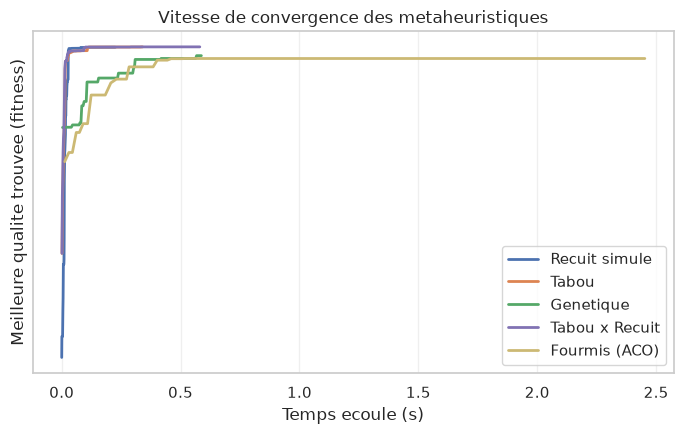

In [10]:
fig = pl.plot_convergence(resultats)
plt.show()

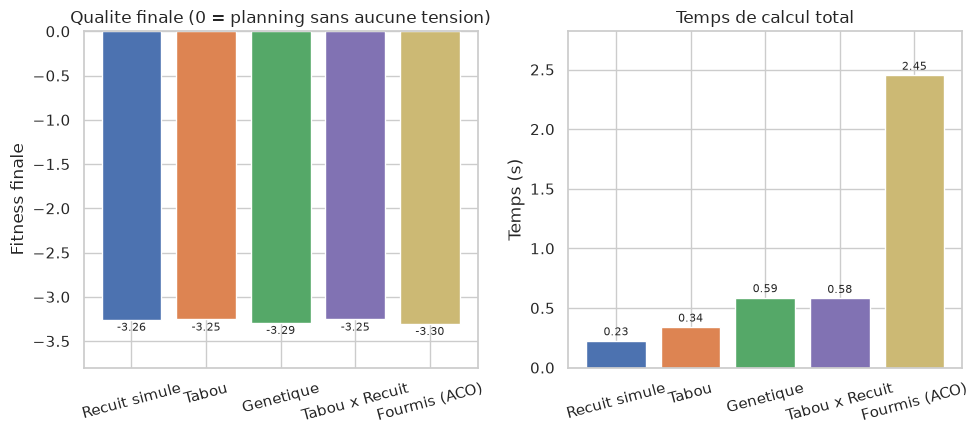

In [11]:
fig = pl.plot_comparaison_barres(resultats)
plt.show()

## 10. Lecture du planning gagnant

On transforme la meilleure solution en tableau lisible
(`solution_to_dataframe`), puis on visualise la charge de chaque vacation et
l'occupation des lits.

In [12]:
meilleure_methode = max(resultats, key=lambda nom: resultats[nom].meilleure_fitness)
meilleure_solution = resultats[meilleure_methode].meilleure_solution
print("Meilleure methode :", meilleure_methode)

planning = op.solution_to_dataframe(problem, meilleure_solution)
display(planning.head(15))

Meilleure methode : Tabou x Recuit


,patient_id,specialite,duree_operatoire,duree_sejour,vacation_id,jour_vacation
0,22,A,28.0,1,0,0
1,37,Autre,38.0,1,1,0
2,13,E,38.0,1,2,0
3,9,M,56.0,1,4,0
4,14,M,78.0,1,4,0
5,18,M,41.0,1,4,0
6,31,N,30.0,1,5,0
7,36,N,87.0,1,5,0
8,42,N,44.0,1,5,0
9,25,A,27.0,1,7,1


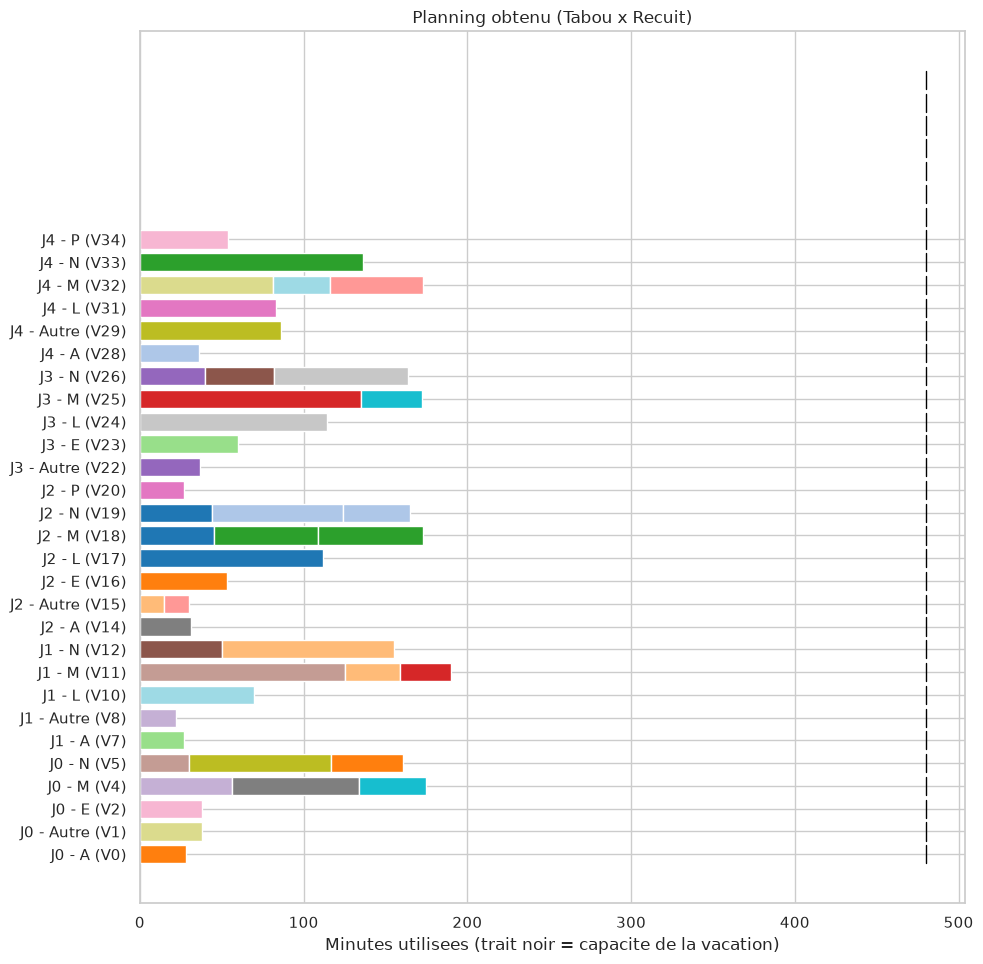

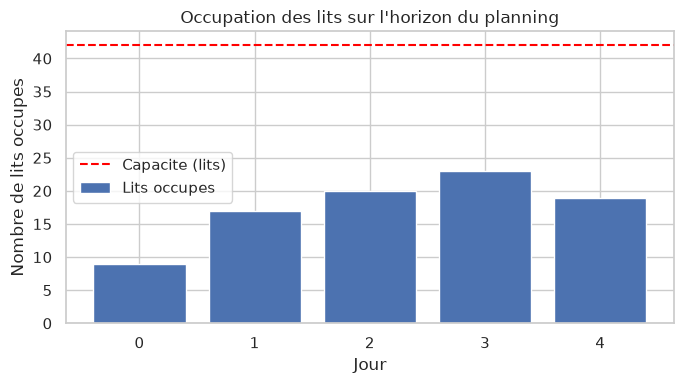

In [13]:
pl.plot_planning(problem, meilleure_solution, titre=f"Planning obtenu ({meilleure_methode})")
plt.show()

pl.plot_occupation_lits(problem, meilleure_solution)
plt.show()

## 11. Validation de l'optimalite (petite instance)

Sur une instance minuscule (7 patients), on peut calculer l'optimum exact par
force brute. C'est la seule taille ou l'enumeration reste possible — au-dela,
le nombre de combinaisons explose, ce qui justifie les metaheuristiques.

In [14]:
pat_s, vac_s = op.small_validation_instance(seed=1)
prob_s = op.PlanningProblem(pat_s, vac_s)
_, f_exact = op.exact_bruteforce(prob_s)

res_s = op.optimize_planning(
    pat_s, vac_s,
    sa_kwargs=dict(n_iter=800),
    tabu_kwargs=dict(n_iter=120, neighborhood_size=10),
    ga_kwargs=dict(pop_size=20, n_gen=80),
    hybrid_kwargs=dict(n_iter=250, neighborhood_size=10),
    aco_kwargs=dict(n_ants=10, n_iter=100),
)
print(f"Optimum exact (force brute) : {f_exact:.6f}\n")
for nom, r in res_s.items():
    ecart = r.meilleure_fitness - f_exact
    statut = "OPTIMUM ATTEINT" if abs(ecart) < 1e-9 else f"ecart = {ecart:.4f}"
    print(f"{nom:<16s} fitness = {r.meilleure_fitness:12.6f}   [{statut}]")

Optimum exact (force brute) : -1114.095973

Recuit simule    fitness = -1114.095973   [OPTIMUM ATTEINT]
Tabou            fitness = -1114.095973   [OPTIMUM ATTEINT]
Genetique        fitness = -1114.095973   [OPTIMUM ATTEINT]
Tabou x Recuit   fitness = -1114.095973   [OPTIMUM ATTEINT]
Fourmis (ACO)    fitness = -1114.095973   [OPTIMUM ATTEINT]


## 12. Limites et bonnes pratiques

- Le proxy `specialite` (CCAM/GHM) doit etre valide cliniquement : il conditionne
  la compatibilite patient-vacation.
- La compatibilite se fait au niveau de la **specialite**, pas d'un chirurgien
  precis ; le modele reste une simplification.
- Les poids de la fonction de cout (`w_vacation`, `w_lits`, `w_balance`) sont
  des choix de gestion : testez leur sensibilite.
- Augmentez `n_iter` / `n_ants` / `pop_size` pour de plus gros volumes.
- Les resultats sont descriptifs et dependants de l'horizon choisi ; ils ne
  constituent pas une decision medicale.
